# Lab 8

## Baseline Centralised Learning and Distributed Robustness Assessment (CL-DRA)
Establish a standard Centralised Learning (CL) model and evaluating its behaviour in both benign and adversarial distributed conditions. Synthetic data are generated to simulate a controlled binary classification task, after which a simple neural classifier is trained using conventional gradient-based optimisation. Model performance should assess not only under normal test conditions but also against Fast Gradient Sign Method (FGSM) perturbations to measure adversarial robustness. A Distributed Client (DC) harness is subsequently used to simulate Non-Independent and Identically Distributed (Non-IID) data across multiple nodes, enabling the calculation of key robustness indicators such as mean client accuracy and instability (variance across clients). Communication Cost (CC) is approximated via parameter count to provide an operational proxy. Overall, CL-DRA establishes the baseline performance, robustness, and system-level variability against which subsequent optimisation methods are compared.

In [1]:
import math, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import optuna  # Part C

# import your script
import harness

harness.set_seed(42)
DEVICE = harness.get_device()
print("Device:", DEVICE)

# Part A: data
X, y = harness.make_synthetic_classification(
    n=8000, d=20, class_sep=2.2, noise=0.8, imbalance=0.55
)

n_train, n_val = 5500, 1500
X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val     = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test, y_test   = X[n_train+n_val:], y[n_train+n_val:]

d = X.shape[1]
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

# Simple model: choose logistic regression or shallow MLP
baseline_model = harness.ShallowMLP(d, h=32)  # or harness.LogisticModel(d)

baseline_model, train_info = harness.train_centralised(
    baseline_model,
    X_train, y_train,
    X_val, y_val,
    lr=3e-3,
    weight_decay=1e-4,
    epochs=25,
    batch_size=256,
    device=DEVICE,
)

# Evaluate on test (clean + FGSM)
Xt = torch.from_numpy(X_test).to(DEVICE)
yt = torch.from_numpy(y_test).to(DEVICE)

baseline_model.eval()
with torch.no_grad():
    test_clean_acc = float((baseline_model(Xt).argmax(dim=1) == yt).float().mean().item())

Xadv = harness.fgsm_attack(baseline_model, Xt, yt, eps=0.15)
with torch.no_grad():
    test_adv_acc = float((baseline_model(Xadv).argmax(dim=1) == yt).float().mean().item())

# Distributed harness metrics
clients = harness.split_clients(X_test, y_test, n_clients=12, iid=False, alpha=0.25)

def model_fn_copy():
    m = harness.ShallowMLP(d, h=32).to(DEVICE)
    m.load_state_dict(baseline_model.state_dict())
    return m

dist = harness.client_metrics(model_fn_copy, clients, eps_adv=0.15, adv_mode="fgsm", device=DEVICE)

# Cost proxies
param_count = harness.count_params(baseline_model)
comm_cost_proxy = param_count  # one full model transmission

baseline_table = pd.DataFrame([{
    "Model": "ShallowMLP(20->32->2)",
    "Val clean acc": train_info["val_clean_acc"],
    "Test clean acc": test_clean_acc,
    "Test FGSM acc (eps=0.15)": test_adv_acc,
    "Distributed mean clean acc": dist["mean_clean_acc"],
    "Distributed mean adv acc": dist["mean_adv_acc"],
    "Instability (var clean acc)": dist["var_clean_acc"],
    "Params": param_count,
    "Comm cost proxy (1x params)": comm_cost_proxy,
    "Train time (s)": train_info["train_time_s"],
}])

baseline_table
print("Observations:")
print(f"- Clean test accuracy: {baseline_table.loc[0,'Test clean acc']:.3f}")
print(f"- Robust (FGSM eps=0.15) test accuracy: {baseline_table.loc[0,'Test FGSM acc (eps=0.15)']:.3f}")
print(f"- Non-IID client instability (var clean acc): {baseline_table.loc[0,'Instability (var clean acc)']:.6f}")
print("- Robust accuracy typically drops under FGSM; magnitude depends on eps and capacity.")
print("- Non-IID splits increase variance across clients; instability term quantifies uneven node performance.")

c:\Users\somto\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'harness'

### Let's analyse the code
Imports pull in standard utilities (math/random/time), numerical/data handling (NumPy, pandas), plotting (Matplotlib), and the ML stack (PyTorch). Module harness contains the reusable functions and models (data generator, attacks, client splitting, training, metrics). Calls to harness.set_seed(42) make randomness reproducible across Python, NumPy, and PyTorch, while harness.get_device() selects GPU if available, otherwise CPU, ensuring the same code runs on different machines with minimal changes.

Data are generated synthetically using make_synthetic_classification, producing 8,000 samples with 20 features, separable classes, added Gaussian noise, and slight class imbalance. Data are split into train/validation/test partitions by slicing. A simple baseline classifier (a shallow MLP with one hidden layer of 32 units, or optionally logistic regression) is trained centrally using gradient-based optimisation via train_centralised, returning the trained model and training-time/validation metrics. Evaluation then measures clean test accuracy and adversarial robustness under an FGSM perturbation with $\epsilon= 0.15$. To simulate a distributed setting, the test set is split into 12 non-IID clients (Dirichlet label skew controlled by $\alpha =0.25$), a fresh copy of the baseline model is evaluated per client, and aggregate statistics are computed: mean clean accuracy, mean adversarial accuracy, and an “instability” proxy (variance of client clean accuracy). Finally, a baseline results table is constructed with performance and cost proxies (parameter count as a communication-cost stand-in), and brief observations are printed to summarise the robustness drop under attack and the performance variability induced by non-IID client splits.

---
## Neuroevolution for Robust Distributed Learning (NRDL)
Introduces a gradient-free optimisation approach based on Neuroevolution (NE) to improve robustness in distributed settings where conventional training may be unreliable or vulnerable to adversarial influence. Rather than updating model parameters through backpropagation, a compact policy vector ($\theta$) representing selected model weights is evolved using an Evolutionary Strategy (ES). Candidate solutions are evaluated using a fitness function that integrates Clean Accuracy (CA), Adversarial Robustness (AR), Communication Cost (CC), and Instability (INS) across Distributed Clients (DCs). A fraction of Malicious Clients (MCs) may be introduced through Label Flipping (LF) to simulate poisoning attacks. Iterative selection and recombination of elite solutions guide the search toward parameter configurations that maintain stable performance under both perturbations and compromised participants. NRDL therefore demonstrates how Gradient-Free Search (GFS) can enhance resilience and fairness across heterogeneous and potentially adversarial distributed environments.

### Multilayer Perceptron (MLP) Formulation

The **Multilayer Perceptron (MLP)** is the simple neural network architecture used as the baseline model in this study. It consists of an input layer, one hidden layer, and an output layer, with each layer fully connected to the next through learnable weights. In this implementation, the MLP transforms the 20-dimensional input features into a 32-dimensional hidden representation using a linear mapping followed by a **Rectified Linear Unit (ReLU)** activation function. ReLU introduces non-linearity by outputting zero for negative values and preserving positive inputs, enabling the network to model more complex decision boundaries than a purely linear classifier. The transformed representation is then projected to a two-class output layer. Such a structure captures basic non-linear relationships while remaining computationally efficient, making it suitable for both centralised training and distributed robustness experiments. The Multilayer Perceptron (MLP) provides the structural foundation that separates representation learning from decision-making. Its lower layers act as a fixed feature extractor that transforms raw inputs into a compact latent representation, while the final layer serves as the adaptive decision boundary. NRDL operates by freezing the feature extraction component of the MLP and evolving only the parameters of the output layer. Such separation allows the evolutionary process to adjust classification behaviour without destabilising the learned internal representation, thereby reducing search complexity and improving robustness under distributed and adversarial conditions.

Given an input vector  
$ \mathbf{x} \in \mathbb{R}^{d} $

the hidden representation  

$\mathbf{h} \in \mathbb{R}^{h}$


is computed as

$ \mathbf{h} = \phi(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) $

where:
$\mathbf{W}_1 \in \mathbb{R}^{h \times d}$ is the weight matrix, $\mathbf{b}_1 \in \mathbb{R}^{h}\$ is the bias vector and $\phi(\cdot)$ is the activation function  

The output layer then produces class scores:

$\mathbf{z} = \mathbf{W}_2 \mathbf{h} + \mathbf{b}_2$

where $\mathbf{W}_2 \in \mathbb{R}^{2 \times h}$, $\mathbf{b}_2 \in \mathbb{R}^{2}$ 

The predicted class is obtained from \(\mathbf{z}\) using a softmax decision rule.

### ReLU Activation Function

The activation function used in the hidden layer is the **Rectified Linear Unit (ReLU)**, defined element-wise as:

$\phi(a) = \text{ReLU}(a) = \max(0, a)$ for any scalar input $a$.

Theta dimension: 66
Neuroevolution (no adversaries)
Neuroevolution (25% poisoned clients, label flips)


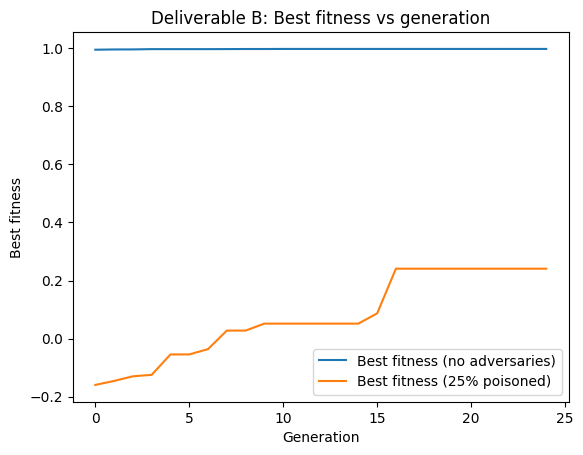

In [ ]:
h = 32
evo_base = harness.FrozenFeatures(d, h=h).to(DEVICE)
with torch.no_grad():
    evo_base.feat[0].weight.copy_(baseline_model.net[0].weight)
    evo_base.feat[0].bias.copy_(baseline_model.net[0].bias)
    evo_base.head.weight.copy_(baseline_model.net[2].weight)
    evo_base.head.bias.copy_(baseline_model.net[2].bias)

for p in evo_base.feat.parameters():
    p.requires_grad_(False)

theta0 = harness.theta_from_head(evo_base.head)
frozen_W = evo_base.feat[0].weight.detach().cpu()
frozen_b = evo_base.feat[0].bias.detach().cpu()

print("Theta dimension:", len(theta0))

clients_eval = harness.split_clients(X_test, y_test, n_clients=12, iid=False, alpha=0.25)

print("Neuroevolution (no adversaries)")
res_clean = harness.evolutionary_search(
    theta0=theta0,
    d=d, h=h,
    frozen_W=frozen_W, frozen_b=frozen_b,
    clients=clients_eval,
    generations=25,
    pop_size=35,
    elite_k=7,
    sigma=0.25,
    eps_adv=0.15,
    malicious_frac=0.0,
    poison_mode="label_flip",
    device=DEVICE,
)

print("Neuroevolution (25% poisoned clients, label flips)")
res_adv = harness.evolutionary_search(
    theta0=theta0,
    d=d, h=h,
    frozen_W=frozen_W, frozen_b=frozen_b,
    clients=clients_eval,
    generations=25,
    pop_size=35,
    elite_k=7,
    sigma=0.25,
    eps_adv=0.15,
    malicious_frac=0.25,
    poison_mode="label_flip",
    device=DEVICE,
)

plt.figure()
plt.plot(res_clean["best_hist"], label="Best fitness (no adversaries)")
plt.plot(res_adv["best_hist"], label="Best fitness (25% poisoned)")
plt.xlabel("Generation")
plt.ylabel("Best fitness")
plt.title("Best fitness vs generation")
plt.legend()
plt.show()


### Let's analyse the code and results
Code prepares a neuroevolution setup by freezing the feature extractor learned during baseline training and evolving only the classifier head. A new `FrozenFeatures` model is created and initialised with the trained weights from the baseline MLP so that representational capacity remains unchanged while adaptation is restricted to the final decision layer. Parameters of the feature block are explicitly frozen to prevent gradient updates, and the head weights are extracted into a vector θ₀, which becomes the starting point for evolutionary search. Test data are then partitioned into 12 non-IID clients to simulate a distributed environment. Two evolutionary runs are executed: one under benign conditions and another where 25% of clients are malicious via label flipping. Each run evolves candidate θ vectors over 25 generations using population sampling, elite selection, and Gaussian mutation, while fitness reflects performance under adversarial perturbations and client variability.

Results show a clear contrast between stable and adversarial environments. In the absence of malicious clients, the best fitness remains near-optimal across generations, indicating that the baseline decision boundary already performs well and evolutionary refinement provides little additional gain. Under poisoning, however, initial fitness starts negative and improves gradually as evolution identifies parameter configurations that better tolerate corrupted labels. Convergence to a lower plateau reflects the structural limits imposed by adversarial influence: performance can recover partially but not to clean conditions. Evolution therefore shifts the decision layer toward solutions that trade raw accuracy for stability across compromised nodes, demonstrating how gradient-free search can adapt to hostile distributed settings even when feature representations remain fixed.

---

## Bayesian Optimisation for Secure Hyperparameter Tuning (BO-SHT) 
Introduces a sample-efficient strategy for improving distributed learning performance when evaluations are costly or influenced by adversarial conditions. Bayesian Optimisation (BO) is used to search over key system Hyperparameters (HPs), such as Learning Rate (LR), Weight Decay (WD), Adversarial Training Strength ($\epsilon$), and Aggregation Rule (AR), including Trimmed Mean (TM) settings where applicable. A single scalar Objective Function (OF) combines Clean Accuracy (CA), Robust Accuracy (RA), and Communication Cost (CC), enabling the tuning process to balance performance and operational constraints. Using a Tree-structured Parzen Estimator (TPE), BO iteratively proposes promising configurations based on past evaluations, allowing efficient navigation of the hyperparameter space. BO-SHT therefore provides a principled method to enhance robustness and efficiency in Distributed Learning (DL) environments without exhaustive search.

[I 2026-02-28 19:35:29,956] A new study created in memory with name: no-name-75482d23-e291-491b-abeb-c227cbb1bf24
[I 2026-02-28 19:35:33,516] Trial 0 finished with value: 0.9933262548911621 and parameters: {'lr': 0.0010253509690168502, 'weight_decay': 0.006351221010640704, 'eps_adv_train': 0.18299848545285127, 'agg': 'mean'}. Best is trial 0 with value: 0.9933262548911621.
[I 2026-02-28 19:35:37,140] Trial 1 finished with value: 0.9933262548911621 and parameters: {'lr': 0.0001434715951720141, 'weight_decay': 0.0029154431891537554, 'eps_adv_train': 0.1502787529358022, 'agg': 'trimmed', 'trim_ratio': 0.2497327922401265}. Best is trial 0 with value: 0.9933262548911621.
[I 2026-02-28 19:35:40,808] Trial 2 finished with value: 0.9933262548911621 and parameters: {'lr': 0.00037419406111184985, 'weight_decay': 5.337032762603957e-06, 'eps_adv_train': 0.045851127463358454, 'agg': 'median'}. Best is trial 0 with value: 0.9933262548911621.
[I 2026-02-28 19:35:44,608] Trial 3 finished with value: 0

Best configuration: {'lr': 0.0061394260508981545, 'weight_decay': 1.7654048052495086e-05, 'eps_adv_train': 0.1300170052944527, 'agg': 'trimmed', 'trim_ratio': 0.23253984700833435}
Best objective: 0.9946595809924652


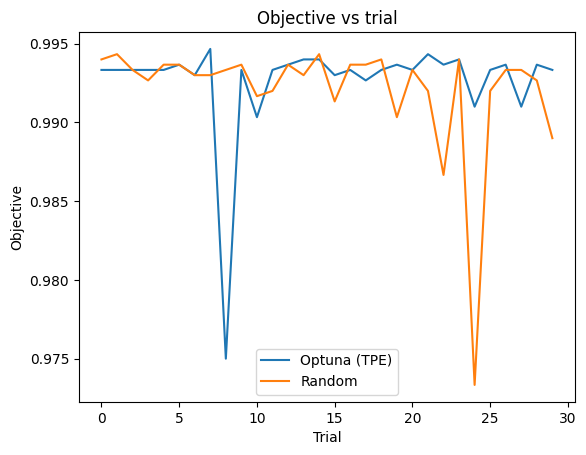

,trial,obj,clean_acc,adv_acc,comm_cost,lr,weight_decay,eps_adv_train,agg,trim_ratio
7,7,0.994660,0.998000,0.991333,70848.0,0.006139,0.000018,0.130017,trimmed,0.232540
21,21,0.994326,0.997333,0.991333,70848.0,0.001459,0.000710,0.208098,trimmed,0.298041
23,23,0.993993,0.997333,0.990667,70848.0,0.004112,0.000555,0.003724,trimmed,0.252203
14,14,0.993993,0.996667,0.991333,70848.0,0.002124,0.000454,0.197867,trimmed,0.299163
13,13,0.993993,0.996000,0.992000,70848.0,0.002276,0.000569,0.196519,trimmed,0.299274
5,5,0.993660,0.996667,0.990667,70848.0,0.000150,0.006245,0.241408,mean,NaN
28,28,0.993660,0.996667,0.990667,70848.0,0.000577,0.000464,0.124584,trimmed,0.206357
19,19,0.993660,0.996000,0.991333,70848.0,0.001201,0.000019,0.214348,trimmed,0.250636


In [ ]:
model_factory = lambda: harness.ShallowMLP(d, h=32)

init_state = {k: v.detach().cpu() for k, v in baseline_model.state_dict().items()}

def eval_config(lr, wd, eps_adv_train, agg, trim_ratio, malicious_frac=0.2, poison_mode="sign_flip"):
    model, info = harness.federated_train_sim(
        model_factory=model_factory,
        X=X_train, y=y_train,
        init_state=init_state,
        n_clients=12,
        rounds=8,
        local_epochs=1,
        batch_size=128,
        lr=lr,
        weight_decay=wd,
        eps_adv_train=eps_adv_train,
        agg=agg,
        trim_ratio=trim_ratio,
        malicious_frac=malicious_frac,
        poison_mode=poison_mode,
        device=DEVICE,
    )
    obj, clean_acc, adv_acc = harness.combined_objective(
        model, X_val, y_val,
        eps_test=0.15,
        comm_cost=info["comm_cost"],
        budget_penalty=1e-10,
        device=DEVICE,
        
    )
    return obj, clean_acc, adv_acc, info["comm_cost"]

def optuna_objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 5e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    eps_adv_train = trial.suggest_float("eps_adv_train", 0.0, 0.25)

    agg = trial.suggest_categorical("agg", ["mean", "median", "trimmed"])
    trim_ratio = 0.0
    if agg == "trimmed":
        trim_ratio = trial.suggest_float("trim_ratio", 0.0, 0.30)

    obj, clean_acc, adv_acc, comm_cost = eval_config(lr, wd, eps_adv_train, agg, trim_ratio)
    trial.set_user_attr("clean_acc", clean_acc)
    trial.set_user_attr("adv_acc", adv_acc)
    trial.set_user_attr("comm_cost", comm_cost)
    return obj

def random_search(n_trials=30):
    rows = []
    for t in range(n_trials):
        lr = 10 ** np.random.uniform(-4, math.log10(5e-2))
        wd = 10 ** np.random.uniform(-6, -2)
        eps_adv_train = np.random.uniform(0.0, 0.25)
        agg = random.choice(["mean", "median", "trimmed"])
        trim_ratio = np.random.uniform(0.0, 0.30) if agg == "trimmed" else 0.0

        obj, clean_acc, adv_acc, comm_cost = eval_config(lr, wd, eps_adv_train, agg, trim_ratio)
        rows.append({
            "trial": t, "obj": obj,
            "clean_acc": clean_acc, "adv_acc": adv_acc,
            "lr": lr, "weight_decay": wd, "eps_adv_train": eps_adv_train,
            "agg": agg, "trim_ratio": trim_ratio,
            "comm_cost": comm_cost
        })
    return pd.DataFrame(rows)

N_TRIALS = 30
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=False)

opt_rows = []
for tr in study.trials:
    opt_rows.append({
        "trial": tr.number,
        "obj": tr.value,
        "clean_acc": tr.user_attrs.get("clean_acc"),
        "adv_acc": tr.user_attrs.get("adv_acc"),
        "comm_cost": tr.user_attrs.get("comm_cost"),
        **tr.params
    })
opt_df = pd.DataFrame(opt_rows).sort_values("trial").reset_index(drop=True)

rand_df = random_search(N_TRIALS)

print("Best configuration:", study.best_trial.params)
print("Best objective:", study.best_value)

plt.figure()
plt.plot(opt_df["trial"], opt_df["obj"], label="Optuna (TPE)")
plt.plot(rand_df["trial"], rand_df["obj"], label="Random")
plt.xlabel("Trial")
plt.ylabel("Objective")
plt.title("Objective vs trial")
plt.legend()
plt.show()

opt_df.sort_values("obj", ascending=False).head(8)

### Let's analyse the code and results
Code sets up Bayesian optimisation over secure federated-learning hyperparameters by wrapping a full distributed training-and-evaluation cycle into a single function call. model_factory defines the model class used in every trial (a shallow MLP), while init_state captures the baseline model weights so each trial starts from the same initialisation rather than random weights. Function eval_config(...) runs federated_train_sim(...), which simulates 12 non-IID clients over 8 communication rounds, applies local training (optionally including adversarial training strength eps_adv_train), injects a malicious fraction of clients using poison_mode="sign_flip" to corrupt updates, and aggregates client updates using either mean, median, or trimmed mean (controlled by agg and trim_ratio). After the federated simulation, combined_objective(...) computes a single scalar objective that blends clean validation accuracy and adversarial (FGSM) accuracy with a small penalty for communication cost, and optuna_objective(...) exposes that scalar to Optuna’s TPE sampler by proposing values for learning rate (lr), weight decay (wd), adversarial training strength (eps_adv_train), and aggregation choice (agg, plus trim_ratio when applicable). A matched-budget random search is implemented for comparison, and both methods are plotted as objective-versus-trial curves.

Results indicate that the best configuration found by **Tree-structured Parzen Estimator (TPE)**. TPE is a Bayesian optimisation method used to efficiently search for good hyperparameter configurations without exhaustively testing all possibilities. Instead of modelling the objective function directly, TPE models two probability distributions: one for parameter settings that lead to good performance and another for those that perform poorly. By comparing these distributions, it selects new hyperparameter values that are more likely to improve the objective. The “tree-structured” aspect refers to its ability to handle conditional parameters, such as tuning a trim ratio only when a trimmed aggregation rule is selected. In this work, TPE guides the search toward combinations of learning rate, adversarial training strength, and aggregation strategy that balance accuracy, robustness, and communication cost in a distributed and adversarial environment. TPE uses a robust aggregation rule (trimmed mean) with a moderate trimming ratio (around 0.23 in the shown run), a learning rate around $6 \times 10^{-3}$, a very small weight decay, and non-zero adversarial training strength ($\epsilon \approx 0.13$), achieving an objective near 0.99466. Plot traces show both Optuna and random search operating in a narrow, high-performing region for most trials, with occasional sharp drops caused by unstable hyperparameter combinations (typically overly aggressive learning rate, unsuitable aggregation under sign-flip poisoning, or an adversarial-training strength that destabilises local updates). Optuna’s advantage appears as avoiding some of the worst configurations and repeatedly sampling robust regions (trimmed/median aggregation with sensible $\epsilon $), while random search exhibits a comparable peak but more erratic dips; such behaviour is consistent with a setting where many configurations work "well enough", but security and stability constraints create failure modes that the TPE sampler learns to avoid.

---

## Deep Optimisation for Secure Distributed Coordination (DO-SDC) 
Introduces a latent-space search approach for solving combinatorial coordination problems in adversarial distributed systems. Instead of optimising directly in the original discrete decision space, Deep Optimisation (DO) learns a compact latent representation of locally optimal solutions using an Autoencoder (AE). Binary decisions, such as selecting trustworthy agents while avoiding Malicious Participants (MPs), are first improved through Local Search (LS) to generate high-quality examples. The AE then captures structural patterns among these solutions, enabling Latent Space Exploration (LSE) through small perturbations that produce coordinated multi-bit changes when decoded. An Objective Function (OF) balances Utility (U), Risk (R), and Communication Cost (CC), allowing DO-SDC to discover resilient configurations that maintain performance even under strengthened adversarial conditions.

In [ ]:
# Part D1: robust agent selection
rng = np.random.default_rng(42)
n_agents = 30
utility = rng.uniform(0.2, 1.0, size=n_agents).astype(np.float32)
comm_cost = rng.uniform(0.05, 0.30, size=n_agents).astype(np.float32)
risk = rng.uniform(0.0, 0.4, size=n_agents).astype(np.float32)

malicious_frac = 0.25
malicious_agents = set(rng.choice(np.arange(n_agents), size=int(round(n_agents*malicious_frac)), replace=False).tolist())
for i in malicious_agents:
    risk[i] += rng.uniform(0.6, 1.0)

def obj_select(x, alpha=1.0, beta=1.2, gamma=0.8):
    x = x.astype(np.float32)
    return float(alpha*(utility @ x) - beta*(risk @ x) - gamma*(comm_cost @ x))

def random_x():
    return (np.random.rand(n_agents) < 0.5).astype(np.int64)

def hill_climb(x0):
    return harness.hill_climb_binary(x0, objective=lambda z: obj_select(z), iters=200)

def random_restart_hc(R=200):
    best_x, best_v = None, -1e9
    vals = []
    for _ in range(R):
        x0 = random_x()
        x, v = hill_climb(x0)
        vals.append(v)
        if v > best_v:
            best_x, best_v = x, v
    return best_x, best_v, vals

best_x_hc, best_v_hc, hc_vals = random_restart_hc(R=200)
print("Baseline hill-climb best objective:", best_v_hc)
print("Selected:", int(best_x_hc.sum()), "Malicious selected:", sum(int(best_x_hc[i]) for i in malicious_agents))
# Generate local optima dataset
R = 500
X_local = []
for _ in range(R):
    x0 = random_x()
    x, _ = hill_climb(x0)
    X_local.append(x.astype(np.float32))
X_local = np.stack(X_local, axis=0).astype(np.float32)

print("Local optima dataset:", X_local.shape, "unique:", len({tuple(row.astype(int)) for row in X_local}))

ae = harness.train_autoencoder(X_local, z_dim=8, epochs=40, batch_size=64, lr=1e-3, device=DEVICE)

@torch.no_grad()
def latent_step(ae, x, step_sigma=0.35):
    xt = torch.from_numpy(x[None, :].astype(np.float32)).to(DEVICE)
    z = ae.encode(xt)
    z_prop = z + torch.randn_like(z) * step_sigma
    x_prop = harness.decode_to_binary(ae, z_prop).cpu().numpy().astype(np.int64).reshape(-1)
    return x_prop

def latent_search(start_x, steps=300, step_sigma=0.35):
    x = start_x.copy().astype(np.int64)
    best_x = x.copy()
    best_v = obj_select(best_x)
    accepted = 0

    for _ in range(steps):
        x_prop = latent_step(ae, x.astype(np.float32), step_sigma=step_sigma)
        # optional local refinement
        x_ref, v_ref = harness.hill_climb_binary(x_prop, objective=lambda z: obj_select(z), iters=50)
        if v_ref > best_v + 1e-9:
            best_x, best_v = x_ref, v_ref
            x = best_x.copy()
            accepted += 1
        else:
            if np.random.rand() < 0.03:
                x = x_ref.copy()
    return best_x, best_v, accepted

start = X_local[np.random.randint(0, len(X_local))].astype(np.int64)
best_x_do, best_v_do, accepted = latent_search(start, steps=300, step_sigma=0.35)

print("Deep Optimisation best objective:", best_v_do, "accepted improvements:", accepted)
print("Selected:", int(best_x_do.sum()), "Malicious selected:", sum(int(best_x_do[i]) for i in malicious_agents))

risk_orig = risk.copy()
risk_boost = risk.copy()
for i in malicious_agents:
    risk_boost[i] += 0.5  # simulate stronger attacker impact

def obj_with_risk(x, risk_vec, alpha=1.0, beta=1.2, gamma=0.8):
    x = x.astype(np.float32)
    return float(alpha*(utility @ x) - beta*(risk_vec @ x) - gamma*(comm_cost @ x))

def eval_solution(x):
    return {
        "obj_normal": obj_with_risk(x, risk_orig),
        "obj_stronger_attack": obj_with_risk(x, risk_boost),
        "selected": int(x.sum()),
        "malicious_selected": int(sum(int(x[i]) for i in malicious_agents)),
    }

comparison = pd.DataFrame([
    {"Method": "Random-restart hill-climb", **eval_solution(best_x_hc)},
    {"Method": "Deep Optimisation (latent search)", **eval_solution(best_x_do)},
])
comparison

Baseline hill-climb best objective: 7.1486406326293945
Selected: 21 Malicious selected: 0
Local optima dataset: (500, 30) unique: 1
Deep Optimisation best objective: 7.1486406326293945 accepted improvements: 0
Selected: 21 Malicious selected: 0


,Method,obj_normal,obj_stronger_attack,selected,malicious_selected
0,Random-restart hill-climb,7.148641,7.148641,21,0
1,Deep Optimisation (latent search),7.148641,7.148641,21,0


### Let's analyse the code and results
Code defines a simplified “secure coordination” problem as binary agent selection with 30 agents, where decision vector $x \in \{0,1\}^{30}$ determines which agents participate. Each agent is assigned a Utility (benefit), Communication Cost, and Risk, while 25\% of the agents are randomly designated as malicious by increasing their risk values to represent potential harm. Objective function `obj_select` evaluates any selection by balancing gained utility against penalties for risk and communication overhead. A baseline solution is obtained using random-restart hill-climbing, which repeatedly improves randomly initialised selections through single-bit flips until no further improvement is possible. Deep Optimisation is then introduced by collecting 500 locally optimal solutions from hill-climbing, training an autoencoder to learn their structural patterns, and exploring the latent space through small perturbations that decode into new candidate selections, optionally refined via local search.

Results show that hill-climbing consistently converged to the same solution across all restarts, as indicated by the dataset having only one unique local optimum. Such behaviour suggests the objective landscape contains a dominant attractor that is easily reached from random starting points. Consequently, the autoencoder receives nearly identical training data and cannot learn meaningful variability, preventing latent perturbations from generating improved candidates; this is reflected in zero accepted improvements and identical best objectives for both methods. Final selections include 21 agents while excluding all malicious participants, demonstrating that the risk penalty successfully prevents adversarial inclusion. Under simulated stronger attack conditions, both approaches retain identical performance, as the optimal configuration already avoids malicious agents and remains unaffected by increased adversarial risk.

## Advanced Task: Simulated Telemetry–Driven Adversarial Robustness Tests (ART-11-SIM) - **Contributes to your coursework**

### Objective
Implement **Requirement 11 – Adversarial Robustness Tests** using *simulated telemetry* aligned with Lab 6 monitoring concepts.  
The system must evaluate how candidate code behaves under controlled perturbations **without inspecting source code**, relying solely on execution-like telemetry.

The harness must test robustness against:

- **Malformed Inputs (MI)**
- **Missing Files (MF)**
- **Randomised Filenames (RF)**
- **Timeout Constraints (TO)**

Results must be **compared against a benign baseline**.

### Core Concept
A **Telemetry Simulator** will emulate sandbox monitoring signals such as:

- File system activity
- Process behaviour
- Network attempts
- Resource usage

Each run produces:

1. Event-level logs  
2. Aggregated behavioural metrics  

The rest of the safety harness treats simulated telemetry **exactly as if it came from a real sandbox**.


### Telemetry Schema

#### Event Log Fields
Each simulated run generates structured logs:

| Field | Description |
|------|-------------|
| `t_ms` | Timestamp |
| `channel` | fs / proc / net / resource |
| `action` | e.g. open, read, spawn, connect |
| `target` | file path / command / host |
| `outcome` | ok / denied / error / timeout |
| `meta` | optional flags (e.g. decoy access) |


#### Aggregated Feature Vector

Each run must output:

- runtime_ms  
- cpu_ms  
- max_rss_mb  
- fs_reads  
- fs_writes  
- fs_unique_paths  
- fs_write_outside_scope  
- fs_decoy_access  
- proc_spawns  
- net_connect_attempts  
- timeout_hit  
- error_type  
- success_label  


### Perturbation Scenarios

#### 1. Malformed Inputs (MI)
Examples:
- Invalid JSON
- Truncated CSV
- Random binary payloads

Expected benign behaviour:
- Controlled parsing failure
- No extra processes or network attempts


#### 2. Missing Files (MF)
Examples:
- Removed input files
- Missing configuration

Expected benign behaviour:
- Clean failure
- No directory scanning


#### 3. Randomised Filenames (RF)
Examples:
- Renamed working directories
- Randomised input/output paths

Expected benign behaviour:
- Use provided paths only
- No broad filesystem traversal


#### 4. Timeout Constraints (TO)
Examples:
- Reduced execution budgets
- Larger workload simulation

Expected benign behaviour:
- Graceful timeout
- No subprocess spawning


### Behaviour Profiles

Simulate at least:

#### Benign Baseline (BB)
- No network activity
- No subprocess spawning
- Limited filesystem access
- Controlled failures

#### Candidate Under Test (CUT)

Example simulated variants:

| Profile | Behaviour |
|--------|-----------|
| Unsafe | Directory scanning, subprocess spawning |
| Fragile | Crashes under malformed inputs |


### Simulation Engine

Function:

simulate_run(profile, scenario, seed) → event_log, features

Must:

- Generate realistic event patterns
- Respect sandbox policy constraints
- Produce consistent resource usage and exit outcomes

### Comparative Evaluation

For each scenario:

1. Run BB and CUT multiple times
2. Compute:

- Behavioural Delta
- Violation Flags
- Success Rates

Example table:

| Scenario | BB Success | CUT Success | Proc Spawns | Net Attempts | Verdict |
|---------|------------|------------|-------------|-------------|---------|

Verdict logic:

- PASS-like: Behaviour matches benign envelope  
- FAIL-like: Violations or unstable behaviour detected  


### Acceptance Criteria

Requirement 11 is satisfied if:

- All four perturbation classes implemented
- BB vs CUT comparison produced
- Telemetry-only analysis used
- Results include interpretation of deviations
- 

### Optional Extension

Adaptive escalation:

If anomalies detected:

Increase severity → re-test → log escalation path

This mimics CI-driven robustness probing.


### Expected Outputs

- Scenario definitions
- Telemetry dataset
- Comparison table
- Anomaly plot
- Interpretation of behavioural differences
